<a href="https://colab.research.google.com/github/miriam-silva/amt4-s1a2026/blob/main/MultiNeural(Census)Tarefa0606.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Naive Bayes| Digest GaussianNB [Fase 1 - census]

## Importar dados do Drive

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [44]:
!pip -q install plotly
!pip -q install yellowbrick

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census


In [46]:
import pickle

In [47]:
with open('/content/drive/MyDrive/AprendizagemDeMaquinaIcoma/am-t4/census.pkl', 'rb') as f:
 X_census_trainamento,Y_census_trainamento,X_census_teste,Y_census_teste = pickle.load(f)

In [48]:
X_census_trainamento.shape ,Y_census_trainamento.shape

((27676, 108), (27676,))

In [49]:
X_census_teste.shape ,Y_census_teste.shape

((4885, 108), (4885,))

In [50]:
from sklearn.naive_bayes import GaussianNB

In [51]:
naive_census_data = GaussianNB()
naive_census_data.fit(X_census_trainamento,Y_census_trainamento)

GaussianNB()

## Criando base Previsora


In [52]:
census_predict = naive_census_data.predict(X_census_teste)

In [53]:
census_predict

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [54]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [56]:
accuracy_score(Y_census_teste, census_predict)

0.4767656090071648

In [57]:
confusion_matrix(Y_census_teste, census_predict)

array([[1172, 2521],
       [  35, 1157]])

In [58]:
from yellowbrick.classifier import ConfusionMatrix

0.4767656090071648

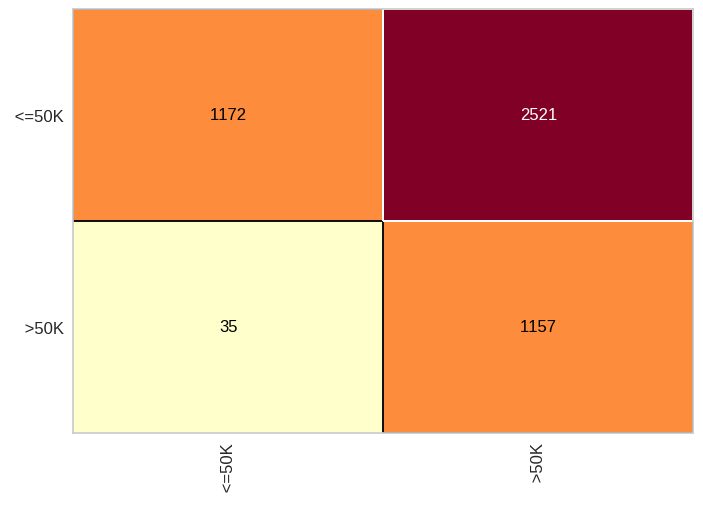

In [59]:
cm_census = ConfusionMatrix(naive_census_data)
cm_census.fit(X_census_trainamento, Y_census_trainamento)
cm_census.score(X_census_teste, Y_census_teste)


# Pipeline Árvore de Decisão | Treemap Base [Fase 2 - census]

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
arvore_census_data = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_census_data.fit(X_census_trainamento,Y_census_trainamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [62]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion="entropy",
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0,
                       random_state=0, splitter='better')

DecisionTreeClassifier(criterion='entropy', random_state=0, splitter='better')

In [63]:
previsao_arvore_census = arvore_census_data.predict(X_census_teste)

In [64]:
previsao_arvore_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [65]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

# Pipeline Medições Harmônicas | Treemap Base [Fase 3 - credit_data]

In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [67]:
accuracy_score(Y_census_teste, previsao_arvore_census)

0.8104401228249745

0.8104401228249745

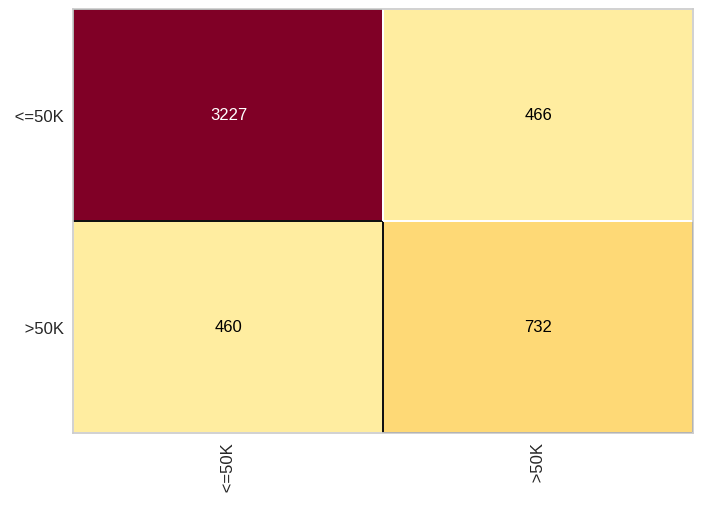

In [68]:
from yellowbrick.classifier import ConfusionMatrix
cm_census = ConfusionMatrix(arvore_census_data)
cm_census.fit(X_census_trainamento, Y_census_trainamento)
cm_census.score(X_census_teste, Y_census_teste)

In [69]:
print(classification_report(Y_census_teste, previsao_arvore_census))

              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      3693
        >50K       0.61      0.61      0.61      1192

    accuracy                           0.81      4885
   macro avg       0.74      0.74      0.74      4885
weighted avg       0.81      0.81      0.81      4885



# Pipeline Random Forest | Digest Dados [Fase 4 - Census_Base]

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
random_census = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_census.fit(X_census_trainamento, Y_census_trainamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion="entropy", max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [72]:
previsores_random = random_census.predict(X_census_teste)
previsores_random

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [73]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [74]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

In [75]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3419,  274],
       [ 512,  680]])

In [76]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      3693
        >50K       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885



# Pipeline Regressão | Digest [Fase 5 - Census_Base]

In [77]:
from sklearn.linear_model import LogisticRegression

In [78]:
regressao_census = LogisticRegression(random_state=1)
regressao_census.fit(X_census_trainamento, Y_census_trainamento)

LogisticRegression(random_state=1)

In [79]:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='12',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', penalty='12', random_state=1)

In [80]:
previsores_random = random_census.predict(X_census_teste)
previsores_random

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [81]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

0.8497441146366428

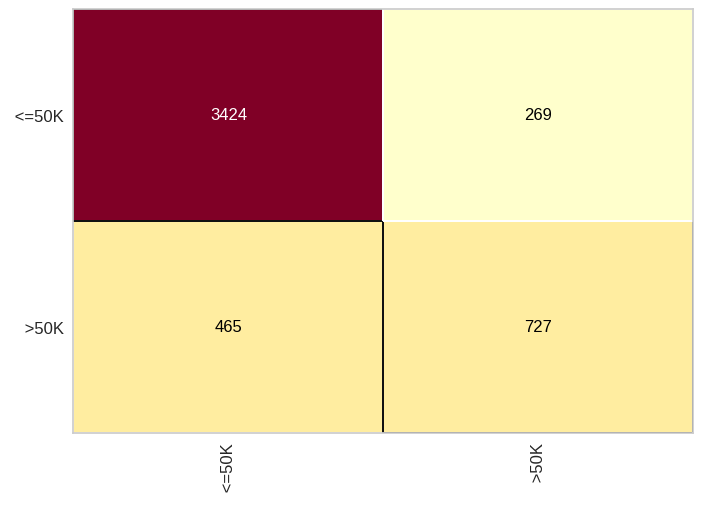

In [82]:
from yellowbrick.classifier import ConfusionMatrix
cm_credit = ConfusionMatrix(regressao_census)
cm_credit.fit(X_census_trainamento, Y_census_trainamento)
cm_credit.score(X_census_teste, Y_census_teste)

In [83]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      3693
        >50K       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885

